Global AO for Gold System Raman has a nonlinear response to amplitude.

I tested it in the following ways:

one_tone: Just one tone on the carrier 

two_tone_minus_222: two tones at +-2.22MHz, the individual frequency is decreased by 2.22MHz


two_tone_plus_222: two tones at +-2.22MHz, the individual frequency is increased by 2.22MHz


two_tone_minus_245: two tones at +-2.45MHz, the individual frequency is decreased by 2.22MHz

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [4]:
one_tone = [12.086, 11.402, 11.179, 11.094, 11.355, 12.197, 13.813, 17.139, 24.45, 47.05]
two_tone_minus_222 = [18.144, 18.152, 18.298, 18.904, 20.223, 20.411, 26.046, 32.83, 47.83]
two_tone_plus_222 = [19.269, 19.031, 19.035, 19.543, 20.768, 23.123, 26.95, 33.71, 48.84]
two_tone_minus_245 = [18.07, 17.997, 18.192, 18.817, 20.1, 22.187, 25.96, 32.72, 47.69]

Power [9.18590065 1.4434609  1.42098963]
Log [ 6.23044958 13.81826119]
Rational [ 7.69564726  2.57694054 -0.03470419]
Exponential [11.43821314 93.13552707  9.64299359]


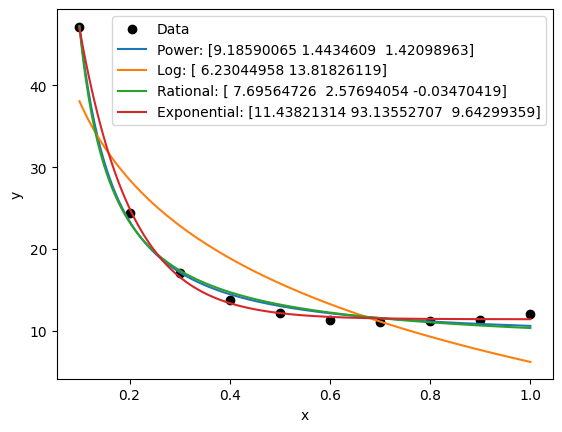

In [6]:

x = np.array([1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1])
y = np.array(one_tone)  # or whichever dataset

# -----------------------
# Candidate models
# -----------------------

# Power law
def power(x, a, b, c):
    return a + b * x**(-c)

# Logarithmic
def log_model(x, a, b):
    return a - b * np.log(x)

# Rational (often works well for saturation/divergence)
def rational(x, a, b, c):
    return a + b / (x + c)

# Exponential (probably not as good here)
def exp_model(x, a, b, c):
    return a + b * np.exp(-c * x)

models = {
    "Power": (power, [10, 1, 1]),
    "Log": (log_model, [10, 5]),
    "Rational": (rational, [10, 1, 0.1]),
    "Exponential": (exp_model, [10, 40, 3]),
}

plt.scatter(x, y, color="k", label="Data")

xx = np.linspace(0.1, 1.0, 300)

for name, (func, guess) in models.items():
    try:
        popt, _ = curve_fit(func, x, y, p0=guess, maxfev=10000)
        plt.plot(xx, func(xx, *popt), label=f"{name}: {popt}")
        print(name, popt)
    except Exception as e:
        print(name, "failed:", e)

plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()